In [4]:
import numpy as np

In [5]:
import matplotlib.pyplot as plt

In [6]:
x = np.array([1,3,5,7,9])
y = np.array([2,4,6,8,10])

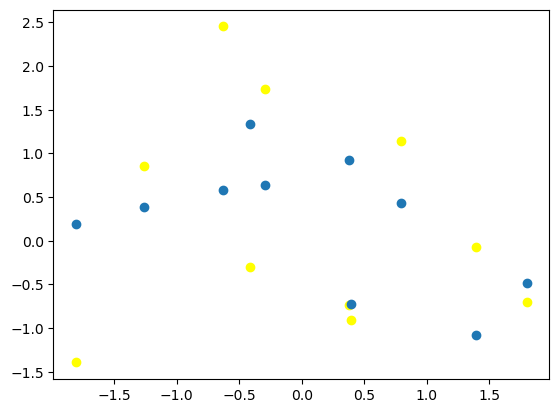

In [7]:
x = np.random.normal(0,1,10)
y = np.random.normal(0,1,10)
y1 = np.random.normal(0,1,10)
plt.scatter(x,y,color="yellow")
plt.scatter(x,y1)
plt.show()

## KNN代码实现

In [8]:
# 样本特征
data_X = [
    [1.3,6],
    [3.5,5],
    [4.2,2],
    [5,3.3],
    [2,9],
    [5,7.5],
    [7.2,4],
    [8.1,8],
    [9,2.5]
]

In [9]:
# 样本标记
data_y = [0,0,0,0,1,1,1,1,1]

In [10]:
# 训练集
X_train = np.array(data_X)
y_train = np.array(data_y)

In [11]:
X_train,y_train

(array([[1.3, 6. ],
        [3.5, 5. ],
        [4.2, 2. ],
        [5. , 3.3],
        [2. , 9. ],
        [5. , 7.5],
        [7.2, 4. ],
        [8.1, 8. ],
        [9. , 2.5]]),
 array([0, 0, 0, 0, 1, 1, 1, 1, 1]))

In [12]:
# 筛选y中为0的
y_train == 0

array([ True,  True,  True,  True, False, False, False, False, False])

In [13]:
# 按y的值，取出x 中对应的行，并取出每个元素的第一个值
z_train_x = X_train[y_train == 0, 0]
z_train_y = X_train[y_train == 0, 1]
z_train_x,z_train_y

(array([1.3, 3.5, 4.2, 5. ]), array([6. , 5. , 2. , 3.3]))

In [14]:
o_train_x = X_train[y_train == 1, 0]
o_train_y = X_train[y_train == 1, 1]
o_train_x,o_train_y

(array([2. , 5. , 7.2, 8.1, 9. ]), array([9. , 7.5, 4. , 8. , 2.5]))

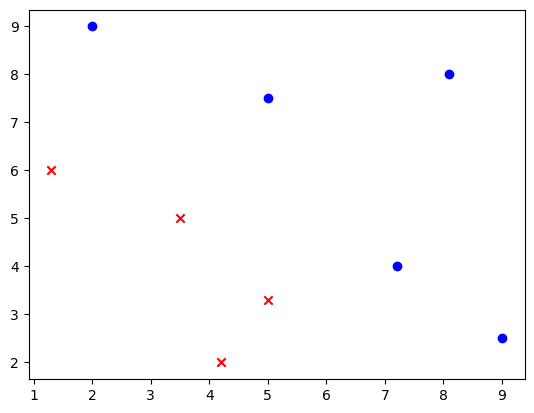

In [26]:
plt.scatter(z_train_x,z_train_y,color='red',marker='x')
plt.scatter(o_train_x,o_train_y,color='blue',marker='o')
plt.show()

In [21]:
# 新的样本点
data_new = np.array([4,5])

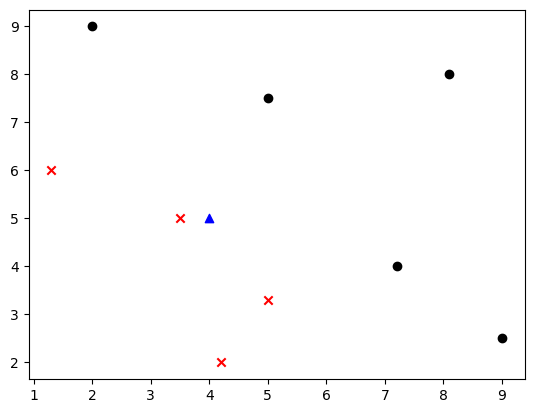

In [29]:
plt.scatter(z_train_x,z_train_y,color='red',marker='x')
plt.scatter(o_train_x,o_train_y,color='black',marker='o')
plt.scatter(data_new[0],data_new[1],color='blue',marker='^')
plt.show()

### **1、计算新样本点与已知样本点的距离**

In [31]:
distances = [np.sqrt(np.sum((data-data_new)**2)) for data in X_train]
distances

[np.float64(2.879236009777594),
 np.float64(0.5),
 np.float64(3.006659275674582),
 np.float64(1.9723082923316022),
 np.float64(4.47213595499958),
 np.float64(2.692582403567252),
 np.float64(3.3526109228480423),
 np.float64(5.080354318352215),
 np.float64(5.5901699437494745)]

### **2、按距离排序**

In [37]:
# 使用argsort()排序 
sort_index = np.argsort(distances)
sort_index

array([1, 3, 5, 0, 2, 6, 4, 7, 8])

### **3、确定k值**

In [35]:
# 假设k为5
k = 5

### **4、距离最近的k个点投票**

In [38]:
first_k = [y_train[i] for i in sort_index[:k]]
first_k

[np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(0)]

### **5、找出最多的类**

In [39]:
from collections import Counter
Counter(first_k)

Counter({np.int64(0): 4, np.int64(1): 1})

In [40]:
Counter(first_k).most_common()

[(np.int64(0), 4), (np.int64(1), 1)]

In [41]:
Counter(first_k).most_common(1)

[(np.int64(0), 4)]

In [42]:
# 取出最多的类别

In [43]:
Counter(first_k).most_common(1)[0][0]

np.int64(0)

### **scikit-learn中的KNN算法**

In [17]:
from sklearn.neighbors import KNeighborsClassifier

In [18]:
knn_classifier = KNeighborsClassifier(n_neighbors=5)

In [19]:
knn_classifier.fit(X_train,y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [25]:
# data_new.reshape(1,2)
data_new.reshape(1,-1)

array([[4, 5]])

In [23]:
knn_classifier.predict(data_new.reshape(1,2))

array([0])

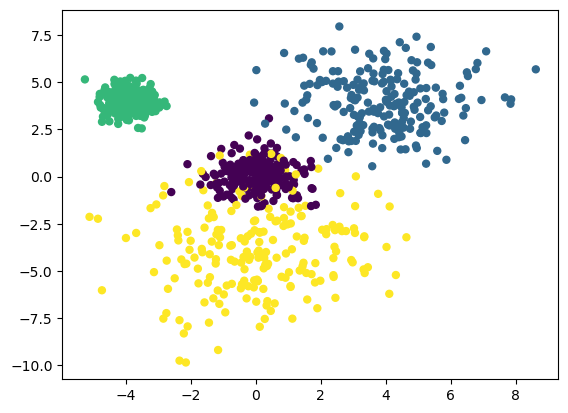

In [30]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

# 1. 生成 4 簇，每簇标准差不一样
a, b = make_blobs(n_samples=800,
                  centers=[[0,0], [4,4], [-4,4], [0,-4]],
                  cluster_std=[0.8, 1.5, 0.5, 2.0],
                  random_state=42)

plt.scatter(a[:, 0], a[:, 1], c=y, cmap='viridis', s=25)
# plt.title('make_blobs 自定义中心与胖瘦')
plt.show()

In [29]:
a, b = make_blobs(n_samples=800,
                  centers=[[0,0], [4,4], [-4,4], [0,-4]],
                  cluster_std=[0.8, 1.5, 0.5, 2.0],
                  random_state=42)
a,b

(array([[-3.63367996,  3.95964171],
        [-3.26172983,  4.69004568],
        [-4.04107559,  4.55864792],
        ...,
        [-2.37519684, -3.38035858],
        [ 0.53478463, -3.35660439],
        [-4.14878175,  4.68785341]], shape=(800, 2)),
 array([2, 2, 2, 0, 3, 0, 0, 2, 3, 1, 3, 0, 3, 3, 0, 2, 1, 2, 3, 3, 3, 1,
        2, 3, 0, 0, 2, 1, 1, 1, 0, 0, 3, 3, 1, 3, 1, 3, 0, 1, 1, 2, 0, 1,
        0, 3, 1, 2, 1, 0, 2, 0, 0, 3, 0, 3, 0, 1, 1, 2, 0, 2, 3, 3, 0, 2,
        3, 2, 2, 3, 2, 0, 2, 0, 3, 3, 2, 0, 1, 3, 1, 2, 3, 0, 1, 1, 2, 2,
        2, 3, 1, 0, 0, 1, 3, 3, 3, 3, 1, 3, 3, 3, 3, 2, 3, 0, 3, 3, 0, 0,
        3, 1, 0, 3, 2, 3, 0, 0, 3, 3, 1, 0, 2, 1, 0, 0, 0, 3, 2, 1, 2, 0,
        2, 0, 3, 0, 0, 3, 3, 3, 2, 1, 2, 2, 0, 2, 0, 1, 0, 3, 3, 3, 2, 0,
        3, 0, 1, 2, 3, 0, 1, 2, 2, 1, 2, 2, 3, 0, 0, 3, 1, 1, 1, 0, 2, 0,
        0, 2, 0, 1, 2, 2, 1, 0, 0, 3, 1, 3, 0, 0, 2, 2, 1, 1, 2, 2, 3, 0,
        2, 1, 2, 3, 0, 2, 1, 2, 1, 2, 2, 0, 0, 1, 0, 1, 2, 0, 0, 1, 2, 0,
        2, 0,

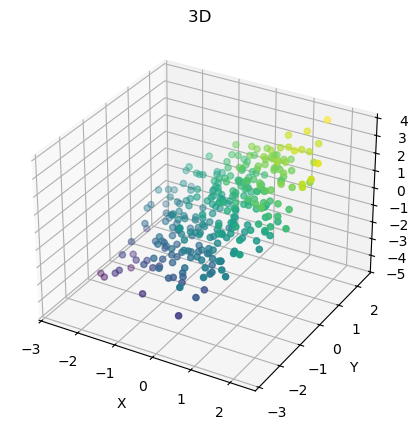

In [32]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D   # 虽无显式调用，但必须导入

fig = plt.figure(figsize=(6, 5))
ax = fig.add_subplot(111, projection='3d')

# 数据
n = 300
x = np.random.randn(n)
y = np.random.randn(n)
z = x + y + np.random.randn(n)*0.5

ax.scatter(x, y, z, c=z, cmap='viridis', s=20)
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
plt.title('3D ')
plt.show()

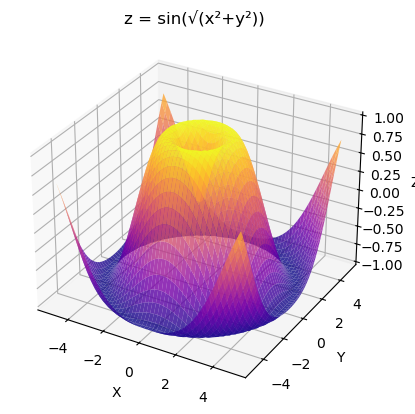

In [33]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
import numpy as np

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# 网格
X = np.linspace(-5, 5, 50)
Y = np.linspace(-5, 5, 50)
X, Y = np.meshgrid(X, Y)
Z = np.sin(np.sqrt(X**2 + Y**2))

# 曲面
ax.plot_surface(X, Y, Z, cmap='plasma', alpha=0.8)
# 线框
# ax.plot_wireframe(X, Y, Z, color='gray')

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
plt.title('z = sin(√(x²+y²))')
plt.show()

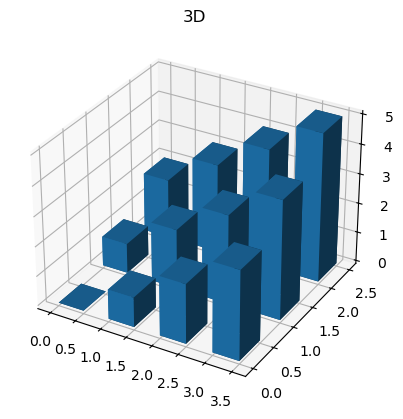

In [35]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

x = np.arange(4)
y = np.arange(3)
x2d, y2d = np.meshgrid(x, y)
z = x2d + y2d

dx = dy = 0.5
ax.bar3d(x2d.ravel(), y2d.ravel(), np.zeros_like(z).ravel(),
         dx, dy, z.ravel(), shade=True)
plt.title('3D')
plt.show()